# Quality assessment tutorial

Welcome to the 2026 BSRN tutorial on quality assessment of solar irradiance data!

The tutorial introduces the basic of how to assess the quality of solar irradiance measurements.

The tutorial uses the [solarpy](https://www.solarpy.org) Python package, which is a Python package dedicated to solar resource assessment.

*The tutorial was developed by Adam R. Jense from the Technical University of Denmark (DTU) with support from Yves-Marie Saint-Drenan (MINES Paris-Tech) and Ioannis Sifnaios (DTU).*

## Get familiar with Google Colab

This notebook can be seamlessly run in Google Colab, a free, no-installation tool for running Python code from your web browser. 

Notebooks are organized by text and code "cells".  You can double-click a cell to start editing it.  To render a text cell or execute a code cell, hit shift+enter.

👉 In the code cell below, calculate ``16*42`` to explore how the notebook and Python work:

In [1]:
1+2

3

## Install pvlib & solarpy

In this tutorial we will be mainly using two Python packages:
- [pvlib](https://pvlib-python.readthedocs.io/): a library for modeling solar irradiance and solar photovoltaic energy systems
- [solarpy](https://www.solarpy.org): a library for working with solar resource data

Since these packages are not standard packages, we need to first install them in the Google Colab environment.

👉 *Action*: Select the code cell below (left click) and execute it (shift+enter) to automatically download and install pvlib and solarpy. In the popup window, you will need to click "Run anyways".

In [ ]:
!pip install pvlib
!pip install git+https://github.com/assessingsolar/solarpy.git

## Import packages

Before a Python package can be used it has to be imported. When importing a package, the package is loaded into Python which requires that the package is already installed (as done in the previous step).

In [2]:
import matplotlib.pyplot as plt  # library for plotting
import numpy as np  # library for numerical operations
import pandas as pd  # library for data manipulation
import pvlib  # library for solar energy calculations
import solarpy  # library for solar data processing and visualization


c:\Users\arajen\AppData\Local\miniconda3\envs\solarpy\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.0.1)/charset_normalizer (3.4.6) doesn't match a supported version!
  warnings.warn(


## Retrieve data from the BSRN

The easiest way to retrieve data from the BSRN is to use the Python function: [``pvlib.iotools.get_bsrn``](https://pvlib-python.readthedocs.io/en/stable/reference/generated/pvlib.iotools.get_bsrn.html).

The function has five required input parameters: ``station`` (3-letter code), ``start``/``end`` time, and ``username``/``password`` to the BSRN FTP server.

👉 *Action*: Change the ``station`` and ``start/end`` parameters in the below code block to retrieve data for the year and station of your choice.

In [3]:
data, meta = pvlib.iotools.get_bsrn(
    station="FLO",  # modify this line
    start="2025-01-01",  # modify this line
    end="2025-12-31",  # modify this line
    username="bsrnftp",
    password="bsrn1",
)

data.head()  # print the first 5 lines of data

c:\Users\arajen\AppData\Local\miniconda3\envs\solarpy\Lib\site-packages\pvlib\iotools\bsrn.py:210: UserWarning: The following files were not found: ['flo1225.dat.gz']
  warnings.warn(f'The following files were not found: {non_existing_files}')  # noqa: E501


,ghi,ghi_std,ghi_min,ghi_max,dni,dni_std,dni_min,dni_max,dhi,dhi_std,dhi_min,dhi_max,lwd,lwd_std,lwd_min,lwd_max,temp_air,relative_humidity,pressure
2025-01-01 00:00:00+00:00,-2.0,0.1,-2.0,-1.0,0.0,0.1,0.0,0.0,-2.0,0.0,-2.0,-2.0,423.0,0.2,422.0,423.0,26.1,76.8,1008.0
2025-01-01 00:01:00+00:00,-2.0,0.0,-2.0,-1.0,0.0,0.1,0.0,0.0,-2.0,0.0,-2.0,-2.0,423.0,0.3,423.0,424.0,26.2,76.8,1008.0
2025-01-01 00:02:00+00:00,-2.0,0.0,-2.0,-1.0,0.0,0.1,0.0,0.0,-2.0,0.0,-2.0,-2.0,425.0,0.5,424.0,425.0,26.1,76.6,1008.0
2025-01-01 00:03:00+00:00,-2.0,0.0,-2.0,-2.0,0.0,0.1,0.0,0.0,-2.0,0.0,-2.0,-2.0,426.0,0.4,425.0,427.0,26.1,76.9,1008.0
2025-01-01 00:04:00+00:00,-2.0,0.0,-2.0,-1.0,0.0,0.0,0.0,0.0,-2.0,0.0,-2.0,-2.0,428.0,0.2,427.0,428.0,26.1,76.9,1008.0


## Visualize data using heatmaps

When doing quality assessment of solar irradiance data one of the first steps should be to visualize the data!

However, one year of 1-minute data is more than half a million data points, which results in overlapping data when using traditional line plots.

An effective way to visualize all individual data points of large datasets is to use heatmaps. For time series data, this can be done using intraday heatmaps, where the y-axis is the hour/minute of day, the x-axis is the date, and the color corresponds to the value of the data point. 

### Colormap
To make heatmaps even more effective, it is useful to define a custom colormap tailored to irradiance data, an example of which is: [``irradiance_colormap_and_norm``](). This colormap is split in two parts: four solid color bands at low irradiance values and a visual continuous colormap for irradiance values above 2 W/m². The solid colorband are: red (<6 W/m²), orange (-6 to -2 W/m²), dark grey (-2 to 0 W/m²), and light grey (0, 2 W/m²). The purpose of these solid color bands is to provide a quick overview of negative thermal offsets and create a stark contrast between nighttime and daytime measurements.

👉 *Action*: Change the ``values`` parameter in the code cell below to visualize the ``"dni"`` measurements.

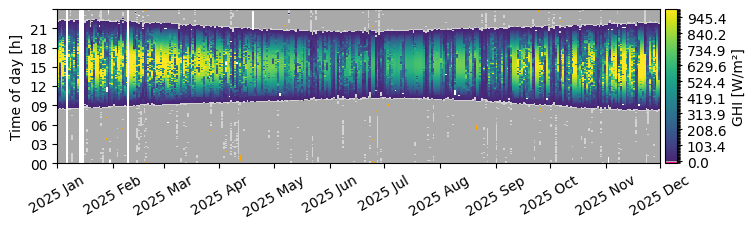

In [4]:
# Load custom colormap and norm
cmap, norm = solarpy.plotting.irradiance_colormap_and_norm(vmax=1000)

# Plot intraday heatmap
fig, ax = solarpy.plotting.plot_intraday_heatmap(
    time=data.index,
    values=data["ghi"],
    cmap=cmap,
    norm=norm,
    colorbar_label="GHI [W/m²]",
)

## Solar position

Next, we need to calculate the solar position for each timestamp, as this information is required to calculate GHI from DHI and DNI and bin irradiance by solar elevation/azimuth angle.

Solar position can be calculated using the function [``pvlib.solarposition.get_solarposition``](https://pvlib-python.readthedocs.io/en/stable/reference/generated/pvlib.solarposition.get_solarposition.html). The function requires the timesteps (including timezone) and location of the station (latitude and longitude). The coordinates of the stations can be foun  in the ``meta`` dictionary retrieved with the measurement data.

👉 *Action*: Run the cell below without modifying the code.

array([<Axes: >, <Axes: >], dtype=object)

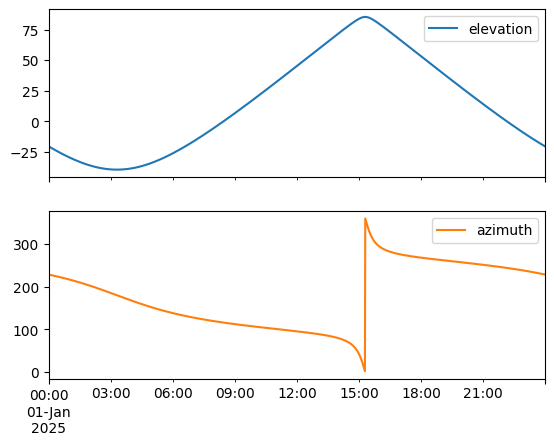

In [12]:
solar_position = pvlib.solarposition.get_solarposition(
    time=data.index,
    latitude=meta["latitude"],
    longitude=meta["longitude"],
)

data["solar_zenith"] = solar_position["apparent_zenith"]
data["solar_azimuth"] = solar_position["azimuth"]

# plot solar position for the first day
solar_position.iloc[: 24*60][["elevation", "azimuth"]].plot(subplots=True)

## BSRN limit checks

The [BSRN limit checks](https://bsrn.awi.de/fileadmin/user_upload/bsrn.awi.de/Publications/BSRN_recommended_QC_tests_V2.pdf) by Long & Dutton specify upper and lower limits for solar irradiance measurements. The limits are defined for GHI, DHI, DNI,  as a function of the extraterrestrial irradiance. Extraterrestrial irradiance is also called "top-of-atmosphere (TOA)" as it is the irradiance received outside of the earth's atmosphere.

There are two sets of limits for each component: the extremely rare limits (ERL), which are expected to be exceeded only in very rare cases, and the physically possible limits (PPL), which are not expected to be exceeded.

The BSRN limits are plotted as red shaded areas. Measurements falling outside the limits can be flagged as suspicious by [``solarpy.quality.bsrn_limits_flag()``](https://www.solarpy.org/en/latest/generated/solarpy.quality.bsrn_limits_flag.html) and should be inspected further. A small amount of flagged data is acceptable, whereas a large amount of flagged data indicates serious issues.

👉 *Action*: Change the ``irradiance`` parameter in the code cell below to visualize the ``"dhi"`` measurements.

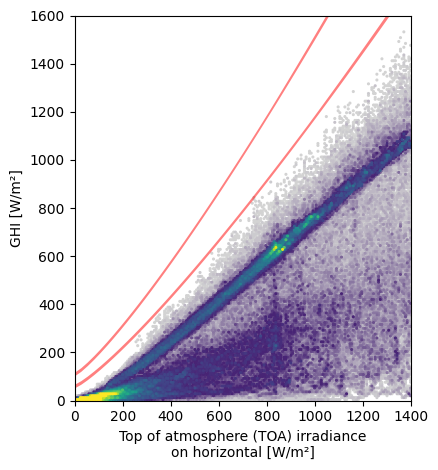

In [6]:
# Calculate extraterrestrial irradiance on a hozontal plane
dni_extra = pvlib.irradiance.get_extra_radiation(data.index)
cos_sza = np.cos(np.deg2rad(solar_position["apparent_zenith"])).clip(lower=0)
ghi_extra = dni_extra * cos_sza

fig, axes = solarpy.plotting.plot_bsrn_limits(
    irradiance=data["ghi"],
    component="ghi",
    ghi_extra=ghi_extra,
)

fig.tight_layout()

## Horizon line

Whenever mountains and hills are present, the direct irradiance is blocked for certain solar positions. While the irradiance measurements represents the local conditions, measurements by shading should be filtered out for certain applications (e.g., validation of satellite data).

Fortunately, it is possible to estimate the local horizon line from freely available topography data.

MINES Paris-Tech offers a web service for retrieving horizon lines for most places on Earth (limited coverage at extreme latitudes). The web service can be accessed in Python using the function [``solarpy.horizon.get_horizon_mines()``](https://www.solarpy.org/en/latest/generated/solarpy.horizon.get_horizon_mines.html).

👉 *Action*: Find the station on [Google Earth](https://earth.google.com/web/) and compare what you see with the horizon line plotted below.

In [7]:
f"Latitude: {meta["latitude"]:2.4f}, {meta["longitude"]:2.4f}"

'Latitude: -27.5330, -48.5170'

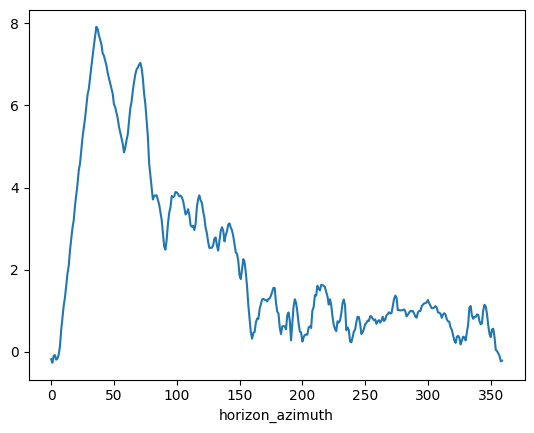

In [8]:
horizon, meta_horizon = solarpy.horizon.get_horizon_mines(
    latitude=meta["latitude"], longitude=meta["longitude"])

horizon.plot()
plt.show()

## Local shading

Shading can be caused by a number of different factors, besides mountains and hills. Some common causes of shading are:
- Buildings
- Vegetation (trees)
- Other instruments

These causes of shading can to a large extent be assessed by assessing the maximum intensity of irradiance in a solar elevation-azimuth space.

👉 *Action*: Execute the code below. Do you think that there is local shading? If so, what do you think is causing it?

👉 *Advanced*: Can you determine the cause of shading using Google Streetview?

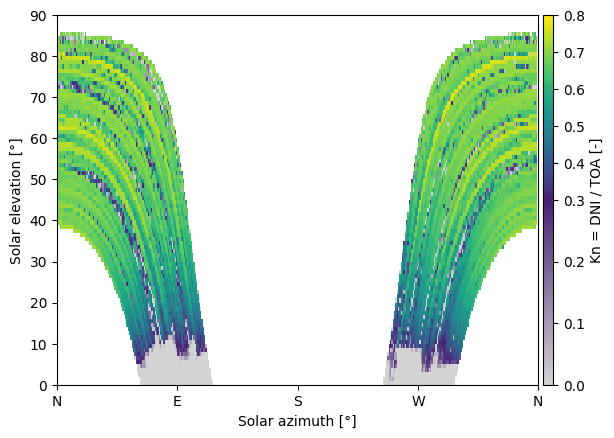

In [ ]:
from matplotlib.colors import TwoSlopeNorm

dni_extra = pvlib.irradiance.get_extra_radiation(data.index)

fig, ax = solarpy.plotting.plot_shading_heatmap(
    value=data["dni"] / dni_extra,
    solar_azimuth=solar_position["azimuth"],
    solar_elevation=solar_position["apparent_elevation"],
    cmap=solarpy.plotting.two_part_colormap(),
    norm=TwoSlopeNorm(vmin=0, vcenter=0.3, vmax=0.8),
    colorbar_label="Kn = DNI / TOA [-]",
    horizon=horizon,
)

## Multiplot

When asessing the quality of many stations and/or years of data it is useful to display all plots together in one figure. We call such a collage of plots for "multiplots".

👉 *Action*: Run the code cell below and inspect the multiplto. What do you see?

*Credit: The multiplot concept was developed by Yves-Marie Saint-Drenan.*

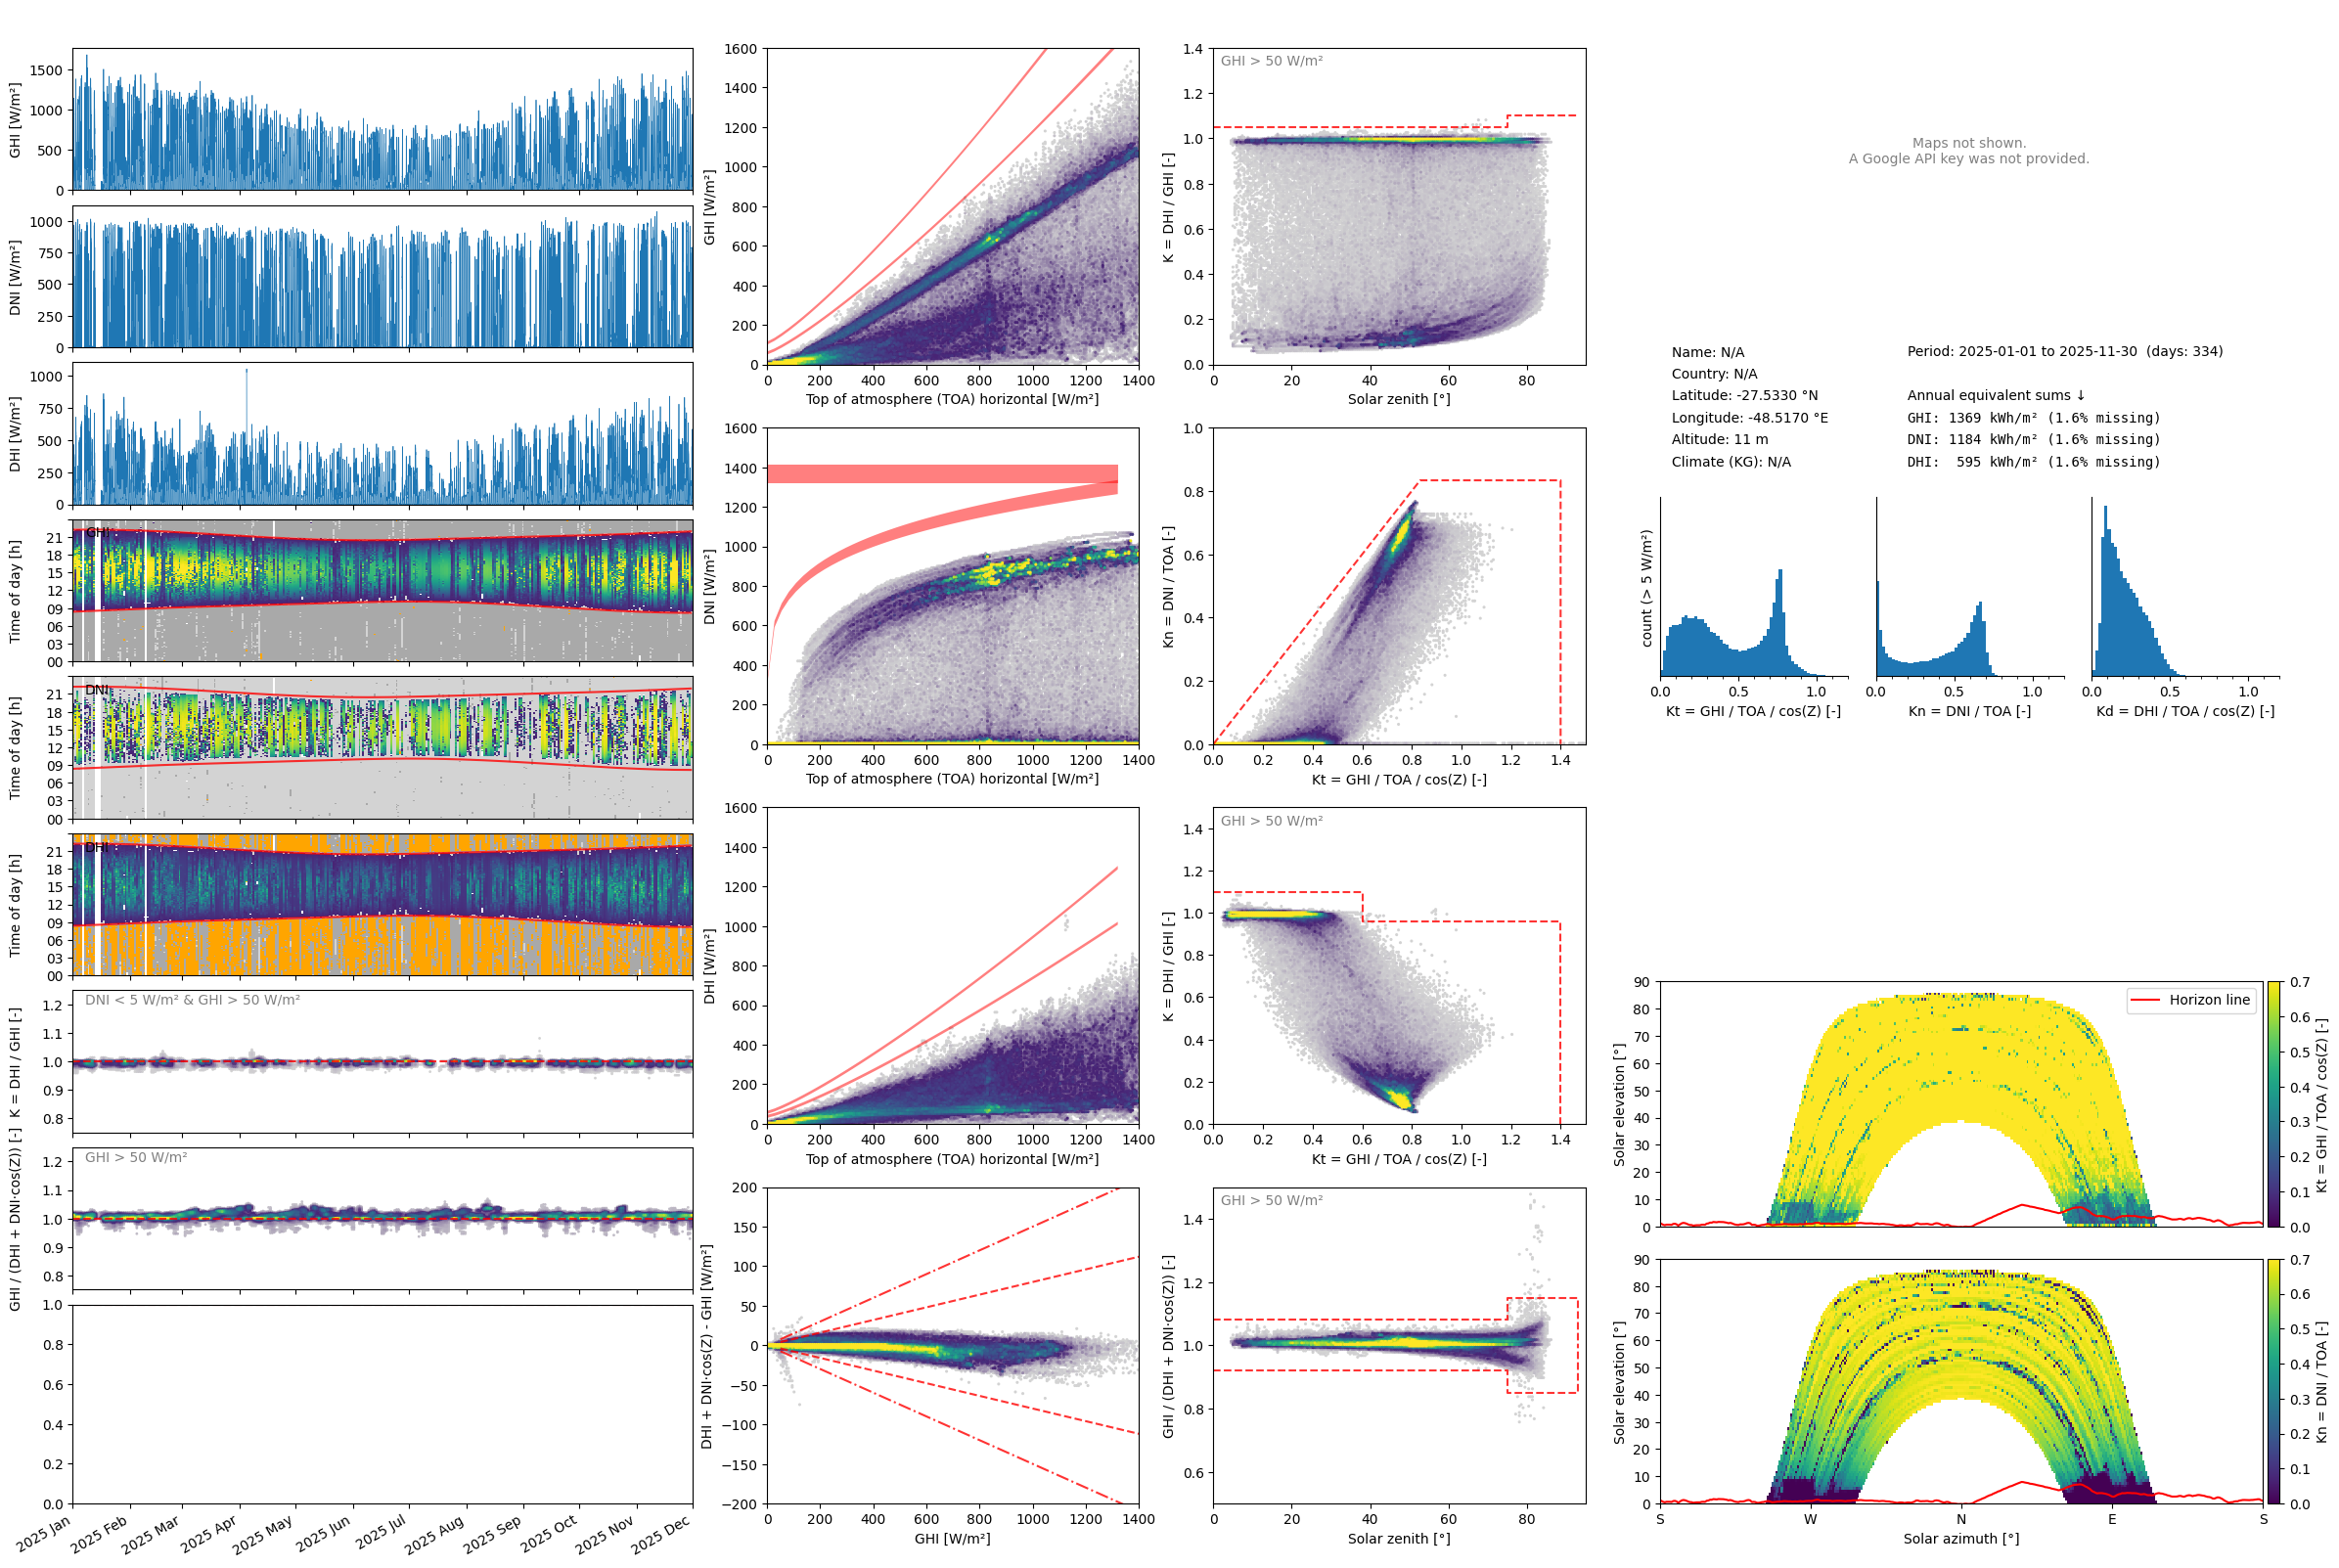

In [15]:
fig, axes = solarpy.plotting.multiplot(
    times=data.index,
    data=data,
    meta=meta,
    horizon=horizon,
)

plt.show()

## Wrapping up

In this tutorial you've been introduced to a few of the many ways at inspecting solar irradiance measurements.

If you want to learn more, you are encourage to check out [solarpy.org](https://www.solarpy.org).